In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import medmnist
from medmnist import dataset
import pennylane as qml
import copy
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [21]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [22]:
# Normalize image in 1D
def l2_normalize(x):
    return x / (torch.norm(x) + 1e-8) # Add 1e-8 to avoid 0 division with dark images

transform = transforms.Compose([
    transforms.Resize((16, 16)),       # Resolution to 16x16
    transforms.ToTensor(),             # Convert to Tensor [0, 1]
    transforms.Lambda(lambda x: x.view(-1)), # Flatten to 1D
    transforms.Lambda(l2_normalize)    # L2 Normalization for Amplitude Embedding
])

In [23]:
# Download Pneunomnia Dataset (0 = Normal, 1 = Pneumonia)
# Already separated in train-test by creators
print("Downloading datasets...")
train_dataset = dataset.PneumoniaMNIST(split='train', download=True, transform=transform)
test_dataset  = dataset.PneumoniaMNIST(split='test', download=True, transform=transform)

In [24]:
def get_balanced_indices(dataset_obj, num_per_class):
    # MedMNIST labels are stored as a numpy array of shape (N, 1)
    labels = dataset_obj.labels.squeeze() 
    
    # Get all indices for class 0 and class 1
    idx_0 = np.where(labels == 0)[0]
    idx_1 = np.where(labels == 1)[0]
    
    # Shuffle the indices
    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)
    
    # Select exactly 'num_per_class' from each class
    selected_0 = idx_0[:num_per_class]
    selected_1 = idx_1[:num_per_class]
    
    # Combine and shuffle again so classes are mixed
    combined_indices = np.concatenate([selected_0, selected_1])
    np.random.shuffle(combined_indices)
    
    return combined_indices.tolist()

train_indices = get_balanced_indices(train_dataset, num_per_class=800)
test_indices  = get_balanced_indices(test_dataset,  num_per_class=200)

train_subset = torch.utils.data.Subset(train_dataset, train_indices)
test_subset  = torch.utils.data.Subset(test_dataset, test_indices)

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_subset, batch_size=16, shuffle=False)

print(f"Training samples: {len(train_subset)}")
print(f"Test samples: {len(test_subset)}")

Training samples: 1600
Test samples: 400


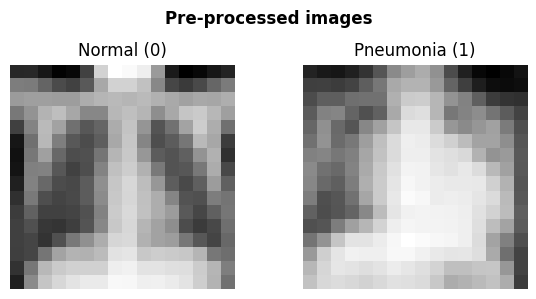

In [25]:
# Visualize samples
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for idx, label_name in [(0, "Normal (0)"), (1, "Pneumonia (1)")]:
    # Search first image from each class
    item_idx = next(i for i, (_, y) in enumerate(train_subset) if y[0] == idx)
    img_1d, label = train_subset[item_idx]
    
    # Visualize at 16x16
    img_2d = img_1d.view(16, 16).numpy()
    
    axes[idx].imshow(img_2d, cmap='gray')
    axes[idx].set_title(label_name)
    axes[idx].axis('off')

plt.suptitle("Pre-processed images", fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:

class ClassicalCNN(nn.Module):
    def __init__(self):
        super(ClassicalCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(2, 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.MaxPool2d(2) 
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 1),
            nn.Sigmoid() # Output probability [0, 1] for BCELoss
        )
        # Total model parameters: 20 + 76 + 65 = 161 parameters

    def forward(self, x):
        # x comes in as [Batch, 256] from our preprocessing (Amplitude Embedding ready)
        # We must reshape it back to 2D image format: [Batch, Channels, Height, Width]
        x = x.view(-1, 1, 16, 16)
        x = self.conv_block(x)
        return self.fc_block(x)

# Initialize the model and verify parameter count
model_classical = ClassicalCNN()
total_params = sum(p.numel() for p in model_classical.parameters() if p.requires_grad)

print(f"Classical CNN initialized with {total_params} trainable parameters.")

Classical CNN initialized with 173 trainable parameters.


In [27]:
# Initialize quantum weights near 0 instead of random
def init_quantum_weights(m):
    if isinstance(m, qml.qnn.TorchLayer):
        nn.init.uniform_(m.weights, -0.1, 0.1)

In [ ]:
# 1. Define the quantum device
n_qubits = 8
dev_ttn = qml.device("default.qubit", wires=n_qubits)

# 2. Define the basic TTN block
# 2 Rotations -> Entanglement -> 2 Rotations (4 params per block)
def ttn_block(weights, wire1, wire2):
    qml.RY(weights[0], wires=wire1)
    qml.RY(weights[1], wires=wire2)
    qml.CNOT(wires=[wire1, wire2])
    qml.RX(weights[2], wires=wire1)
    qml.RX(weights[3], wires=wire2)

# 3. Define the QNode
@qml.qnode(dev_ttn, interface="torch")
def qnode_ttn_amp(inputs, weights):
    # --- State Preparation ---
    # Encodes 256 features into the amplitudes of 8 qubits
    qml.AmplitudeEmbedding(features=inputs, wires=range(n_qubits), normalize=True)
    
    weight_idx = 0
    
    # --- TTN Ansatz (Hierarchical Reduction) ---
    
    # Layer 1: 8 qubits -> 4 blocks
    # Wires: (0,1), (2,3), (4,5), (6,7)
    for i in range(0, 8, 2):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+1)
        weight_idx += 4
        
    # Layer 2: 4 active qubits -> 2 blocks
    # Active wires: 1, 3, 5, 7. Pairs: (1,3), (5,7)
    for i in range(1, 8, 4):
        ttn_block(weights[weight_idx:weight_idx+4], i, i+2)
        weight_idx += 4
        
    # Layer 3: 2 active qubits -> 1 block
    # Active wires: 3, 7. Pair: (3,7)
    ttn_block(weights[weight_idx:weight_idx+4], 3, 7)
    
    # Measure the expectation value of the final sink qubit
    return qml.expval(qml.PauliZ(7))

# 4. PyTorch Wrapper
class QuantumTTN_Amp(nn.Module):
    def __init__(self):
        super(QuantumTTN_Amp, self).__init__()
        
        # A 8-qubit TTN has 7 blocks (4 + 2 + 1). 
        # 7 blocks * 4 weights per block = 28 parameters.
        weight_shapes = {"weights": (28,)}
        self.qlayer = qml.qnn.TorchLayer(qnode_ttn_amp, weight_shapes)

    def forward(self, x):
        # x shape is [Batch, 256]. Amplitude embedding expects exactly this.
        out = self.qlayer(x)
        # Map expectation value [-1, 1] to probability [0, 1]
        prob = ((out + 1.0) / 2.0).view(-1, 1) 
        return prob

# Initialize model and check parameters
model_ttn = QuantumTTN_Amp()
total_params_ttn = sum(p.numel() for p in model_ttn.parameters() if p.requires_grad)

print(f"Quantum TTN initialized with {total_params_ttn} trainable parameters.")

Quantum TTN initialized with 28 trainable parameters.


In [29]:
# 1. Define the quantum device
n_qubits = 8
dev_qcnn = qml.device('default.qubit', wires=n_qubits)

# 2. Define the QCNN building blocks
def conv_layer(weights, wires):
    """
    Applies a parameterized 2-qubit unitary to adjacent pairs.
    Periodic boundary conditions (ring connection).
    Requires 6 parameters per pair.
    """
    n = len(wires)
    # Generate pairs: (0,1), (1,2) ... (n-1, 0)
    pairs = list(zip(wires, wires[1:] + [wires[0]]))
    
    # If only 2 wires, we only need 1 pair to entangle them, not a redundant ring
    if n == 2:
        pairs = [ (wires[0], wires[1]) ]

    for idx, (w0, w1) in enumerate(pairs):
        w = weights[idx]
        # Local rotations
        qml.RY(w[0], wires=w0)
        qml.RY(w[1], wires=w1)
        # Entanglement
        qml.CNOT(wires=[w0, w1])
        # Post-entanglement rotations
        qml.RY(w[2], wires=w0)
        qml.RY(w[3], wires=w1)
        qml.CNOT(wires=[w1, w0])
        qml.RY(w[4], wires=w0)
        qml.RY(w[5], wires=w1)

def pool_layer(weights, sinks, sources):
    """
    Pooling: transfers information from source to sink, and "traces out" source.
    Requires 2 parameters per pair.
    """
    for idx, (snk, src) in enumerate(zip(sinks, sources)):
        w = weights[idx]
        qml.CRZ(w[0], wires=[src, snk])
        qml.CNOT(wires=[snk, src])
        qml.RY(w[1], wires=snk)

# Parameter Counts:
# Conv1: 8 pairs * 6 = 48
# Pool1: 4 pairs * 2 = 8
# Conv2: 4 pairs * 6 = 24
# Pool2: 2 pairs * 2 = 4
# Conv3: 1 pair  * 6 = 6
# Pool3: 1 pair  * 2 = 2
# Total Parameters: 92

N_C1, N_P1 = 48, 8
N_C2, N_P2 = 24, 4
N_C3, N_P3 = 6,  2
TOTAL_QCNN_PARAMS = N_C1 + N_P1 + N_C2 + N_P2 + N_C3 + N_P3

# 3. Define the QNode
@qml.qnode(dev_qcnn, interface='torch')
def qnode_qcnn_amp(inputs, weights):
    # --- State Preparation ---
    qml.AmplitudeEmbedding(features=inputs, wires=range(n_qubits), normalize=True)
    
    idx = 0
    
    # --- Layer 1 ---
    # Conv1 (8 wires)
    all_wires = list(range(8))
    conv_layer(weights[idx : idx+N_C1].reshape(-1, 6), all_wires)
    idx += N_C1
    
    # Pool1 (8 -> 4)
    sinks1   = [0, 2, 4, 6]
    sources1 = [1, 3, 5, 7]
    pool_layer(weights[idx : idx+N_P1].reshape(-1, 2), sinks1, sources1)
    idx += N_P1
    
    # --- Layer 2 ---
    # Conv2 (4 wires)
    conv_layer(weights[idx : idx+N_C2].reshape(-1, 6), sinks1)
    idx += N_C2
    
    # Pool2 (4 -> 2)
    sinks2   = [0, 4]
    sources2 = [2, 6]
    pool_layer(weights[idx : idx+N_P2].reshape(-1, 2), sinks2, sources2)
    idx += N_P2
    
    # --- Layer 3 ---
    # Conv3 (2 wires)
    conv_layer(weights[idx : idx+N_C3].reshape(-1, 6), sinks2)
    idx += N_C3
    
    # Pool3 (2 -> 1)
    sinks3   = [0]
    sources3 = [4]
    pool_layer(weights[idx : idx+N_P3].reshape(-1, 2), sinks3, sources3)
    
    # Measure the final remaining qubit
    return qml.expval(qml.PauliZ(0))

# 4. PyTorch Wrapper
class QuantumQCNN_Amp(nn.Module):
    def __init__(self):
        super(QuantumQCNN_Amp, self).__init__()
        weight_shapes = {'weights': (TOTAL_QCNN_PARAMS,)}
        self.qlayer = qml.qnn.TorchLayer(qnode_qcnn_amp, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        # Map [-1, 1] expectation value to [0, 1] probability
        prob = ((out + 1.0) / 2.0).view(-1, 1)
        return prob

# Initialize and check parameters
model_qcnn = QuantumQCNN_Amp()
total_params_qcnn = sum(p.numel() for p in model_qcnn.parameters() if p.requires_grad)

print(f"Quantum CNN initialized with {total_params_qcnn} trainable parameters.")

Quantum CNN initialized with 92 trainable parameters.


In [30]:
def train_and_evaluate(model, optimizer, train_loader, test_loader, epochs=30):
    criterion = nn.BCELoss()
    best_loss = float('inf')
    best_acc = 0.0
    best_epoch = 0
    best_model_weights = None
    
    history = {'tr_loss': [], 'te_loss': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        tr_loss = 0.0
        for X_batch, y_batch in train_loader:
            y_batch = y_batch.float().view(-1, 1)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * len(y_batch)
        tr_loss /= len(train_loader.dataset)
        
        # Evaluation
        model.eval()
        te_loss = 0.0
        corrects = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                y_batch = y_batch.float().view(-1, 1)
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                te_loss += loss.item() * len(y_batch)
                
                preds_cls = (preds >= 0.5).int()
                corrects += (preds_cls == y_batch.int()).sum().item()
                total += len(y_batch)
                
        te_loss /= len(test_loader.dataset)
        acc = corrects / total
        
        history['tr_loss'].append(tr_loss)
        history['te_loss'].append(te_loss)
        
        # Save best model weights
        if te_loss < best_loss:
            best_loss = te_loss
            best_acc = acc
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            
    model.load_state_dict(best_model_weights)
    return best_loss, best_acc, best_epoch, history, model

In [31]:
print("Starting Grid Search...")
n_epochs = 30

# Grid Search for Classical CNN
cnn_lrs = [0.05, 0.01, 0.005, 0.001, 0.0005]
cnn_w_decays = [1e-4, 1e-5]

best_cnn_config = None
best_cnn_loss = float('inf')
best_cnn_model = None

print("\nSearching hiperparameters for Classical CNN")
for lr in cnn_lrs:
    for wd in cnn_w_decays:
        model = ClassicalCNN()
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        
        print(f"Training CNN -> LR: {lr}, L2: {wd}", end="... ")
        val_loss, val_acc, best_ep, hist, trained_model = train_and_evaluate(model, opt, train_loader, test_loader, epochs=n_epochs)
        print(f"Best Test Loss: {val_loss:.4f} (Epoch {best_ep}) | Accuracy: {val_acc:.4f}")
        
        if val_loss < best_cnn_loss:
            best_cnn_loss = val_loss
            best_cnn_config = {'lr': lr, 'wd': wd, 'hist': hist}
            best_cnn_model = trained_model

# Grid Search for Quantum TTN
quantum_lrs = [0.05, 0.01, 0.005, 0.001, 0.0005] 

best_ttn_config = None
best_ttn_loss = float('inf')
best_ttn_model = None

print("\nSearching hiperparameters for Quantum TTN")
for lr in quantum_lrs:
    model = QuantumTTN_Amp()
    model.apply(init_quantum_weights) #  Apply initialization near 0
    opt = optim.Adam(model.parameters(), lr=lr)
    
    print(f"Training TTN -> LR: {lr}", end="... ")
    val_loss, val_acc, best_ep, hist, trained_model = train_and_evaluate(model, opt, train_loader, test_loader, epochs=n_epochs)
    print(f"Best Test Loss: {val_loss:.4f} (Epoch {best_ep}) | Accuracy: {val_acc:.4f}")
    
    if val_loss < best_ttn_loss:
        best_ttn_loss = val_loss
        best_ttn_config = {'lr': lr, 'hist': hist}
        best_ttn_model = trained_model

# Grid Search for Quantum QCNN
best_qcnn_config = None
best_qcnn_loss = float('inf')
best_qcnn_model = None

print("\nSearching hiperparameters for Quantum QCNN")
for lr in quantum_lrs:
    model = QuantumQCNN_Amp()
    model.apply(init_quantum_weights) # Apply initialization near 0
    opt = optim.Adam(model.parameters(), lr=lr)
    
    print(f"Training QCNN -> LR: {lr}", end="... ")
    val_loss, val_acc, best_ep, hist, trained_model = train_and_evaluate(model, opt, train_loader, test_loader, epochs=n_epochs)
    print(f"Best Test Loss: {val_loss:.4f} (Epoch {best_ep}) | Accuracy: {val_acc:.4f}")
    
    if val_loss < best_qcnn_loss:
        best_qcnn_loss = val_loss
        best_qcnn_config = {'lr': lr, 'hist': hist}
        best_qcnn_model = trained_model

print("\n=== GRID SEARCH SUMMARY ===")
print(f"Best CNN Clasical : LR={best_cnn_config['lr']}, Weight_Decay={best_cnn_config['wd']}")
print(f"Best Quantum TTN : LR={best_ttn_config['lr']}")
print(f"Best Quantum QCNN: LR={best_qcnn_config['lr']}")

Starting Grid Search...

Searching hiperparameters for Classical CNN
Training CNN -> LR: 0.05, L2: 0.0001... 

Best Test Loss: 0.3352 (Epoch 18) | Accuracy: 0.8750
Training CNN -> LR: 0.05, L2: 1e-05... Best Test Loss: 0.3734 (Epoch 17) | Accuracy: 0.8400
Training CNN -> LR: 0.01, L2: 0.0001... Best Test Loss: 0.3153 (Epoch 17) | Accuracy: 0.8750
Training CNN -> LR: 0.01, L2: 1e-05... Best Test Loss: 0.3906 (Epoch 12) | Accuracy: 0.8100
Training CNN -> LR: 0.005, L2: 0.0001... Best Test Loss: 0.3243 (Epoch 10) | Accuracy: 0.8575
Training CNN -> LR: 0.005, L2: 1e-05... Best Test Loss: 0.3465 (Epoch 23) | Accuracy: 0.8625
Training CNN -> LR: 0.001, L2: 0.0001... Best Test Loss: 0.4075 (Epoch 11) | Accuracy: 0.8100
Training CNN -> LR: 0.001, L2: 1e-05... Best Test Loss: 0.3247 (Epoch 13) | Accuracy: 0.8750
Training CNN -> LR: 0.0005, L2: 0.0001... Best Test Loss: 0.3479 (Epoch 29) | Accuracy: 0.8600
Training CNN -> LR: 0.0005, L2: 1e-05... Best Test Loss: 0.3433 (Epoch 14) | Accuracy: 0.8500

Searching hiperparameters for Quantum TTN
Training TTN -> LR: 0.05... Best Test Loss: 0.6485 (Epoch 18) | 

In [32]:
# 4. Final Evaluation & Metrics Calculation
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch)
            preds_cls = (preds >= 0.5).int() # Convert probabilities to 0 or 1
            all_preds.extend(preds_cls.numpy().flatten())
            all_labels.extend(y_batch.numpy().flatten())
    return np.array(all_preds), np.array(all_labels)

In [33]:

# 2. History Dictionary to store losses
cnn_preds,  true_labels = get_predictions(best_cnn_model, test_loader)
ttn_preds,  _           = get_predictions(best_ttn_model, test_loader)
qcnn_preds, _           = get_predictions(best_qcnn_model, test_loader)

# Y para la gráfica de Loss, saca los historiales ganadores:
history = {
    'cnn_tr_loss': best_cnn_config['hist']['tr_loss'], 
    'cnn_te_loss': best_cnn_config['hist']['te_loss'],
    'ttn_tr_loss': best_ttn_config['hist']['tr_loss'], 
    'ttn_te_loss': best_ttn_config['hist']['te_loss'],
    'qcnn_tr_loss': best_qcnn_config['hist']['tr_loss'], 
    'qcnn_te_loss': best_qcnn_config['hist']['te_loss']
}


In [34]:
# Calculate Metrics
def calc_metrics(preds, trues):
    acc = accuracy_score(trues, preds)
    rec = recall_score(trues, preds, zero_division=0)
    f1  = f1_score(trues, preds, zero_division=0)
    cm  = confusion_matrix(trues, preds)
    return acc, rec, f1, cm

In [35]:
cnn_acc, cnn_rec, cnn_f1, cnn_cm = calc_metrics(cnn_preds, true_labels)
ttn_acc, ttn_rec, ttn_f1, ttn_cm = calc_metrics(ttn_preds, true_labels)
qcnn_acc, qcnn_rec, qcnn_f1, qcnn_cm = calc_metrics(qcnn_preds, true_labels)

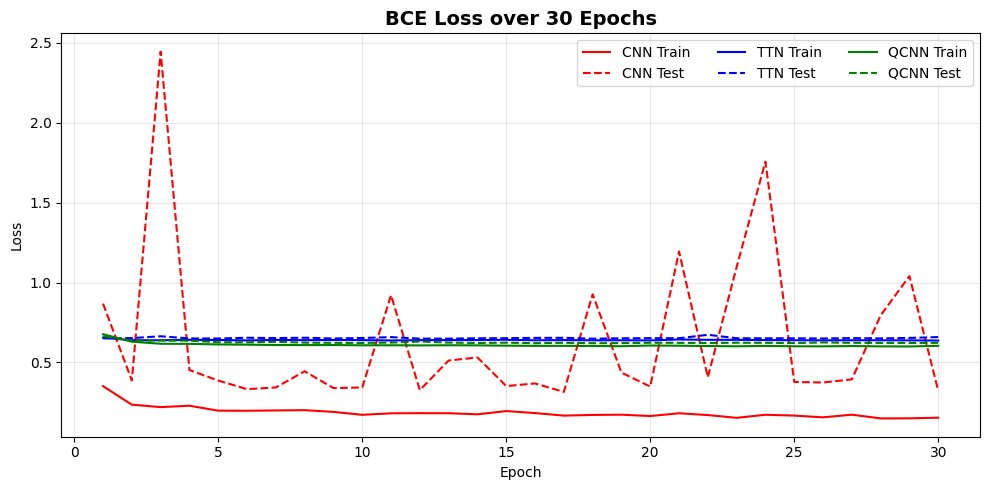

In [36]:
# ==========================================
# 5. PLOTTING THE RESULTS
# ==========================================
plt.style.use('default')

# --- PLOT 1: Loss Curves ---
fig1, ax1 = plt.subplots(figsize=(10, 5))
epochs_range = range(1, n_epochs + 1)

ax1.plot(epochs_range, history['cnn_tr_loss'],  'r-',  label='CNN Train')
ax1.plot(epochs_range, history['cnn_te_loss'],  'r--', label='CNN Test')
ax1.plot(epochs_range, history['ttn_tr_loss'],  'b-',  label='TTN Train')
ax1.plot(epochs_range, history['ttn_te_loss'],  'b--', label='TTN Test')
ax1.plot(epochs_range, history['qcnn_tr_loss'], 'g-',  label='QCNN Train')
ax1.plot(epochs_range, history['qcnn_te_loss'], 'g--', label='QCNN Test')

ax1.set_title("BCE Loss over 30 Epochs", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', ncol=3)
plt.tight_layout()
plt.show()

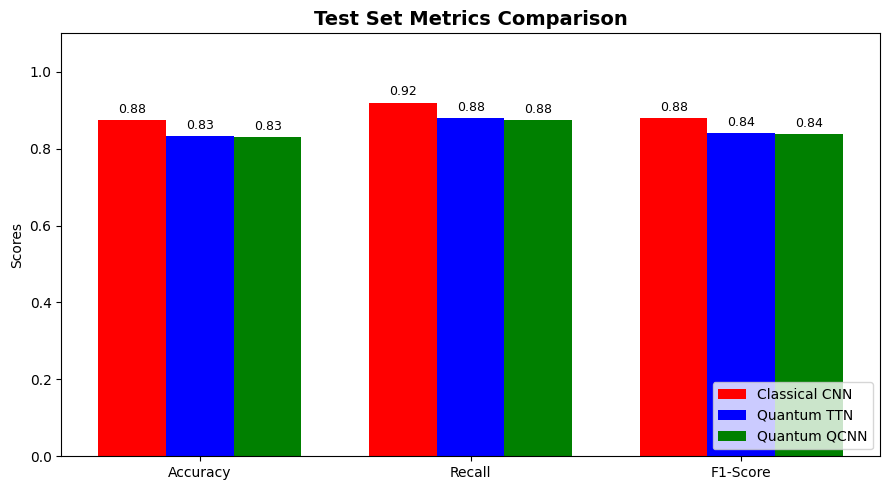

In [37]:
# --- PLOT 2: Bar Plots (Accuracy, Recall, F1-Score) ---
fig2, ax2 = plt.subplots(figsize=(9, 5))

labels = ['Accuracy', 'Recall', 'F1-Score']
cnn_scores  = [cnn_acc, cnn_rec, cnn_f1]
ttn_scores  = [ttn_acc, ttn_rec, ttn_f1]
qcnn_scores = [qcnn_acc, qcnn_rec, qcnn_f1]

x = np.arange(len(labels))  # label locations
width = 0.25  # width of the bars

rects1 = ax2.bar(x - width, cnn_scores,  width, label='Classical CNN', color='red')
rects2 = ax2.bar(x,         ttn_scores,  width, label='Quantum TTN', color='blue')
rects3 = ax2.bar(x + width, qcnn_scores, width, label='Quantum QCNN', color='green')

ax2.set_ylabel('Scores')
ax2.set_title('Test Set Metrics Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1.1)
ax2.legend(loc='lower right')

# Add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

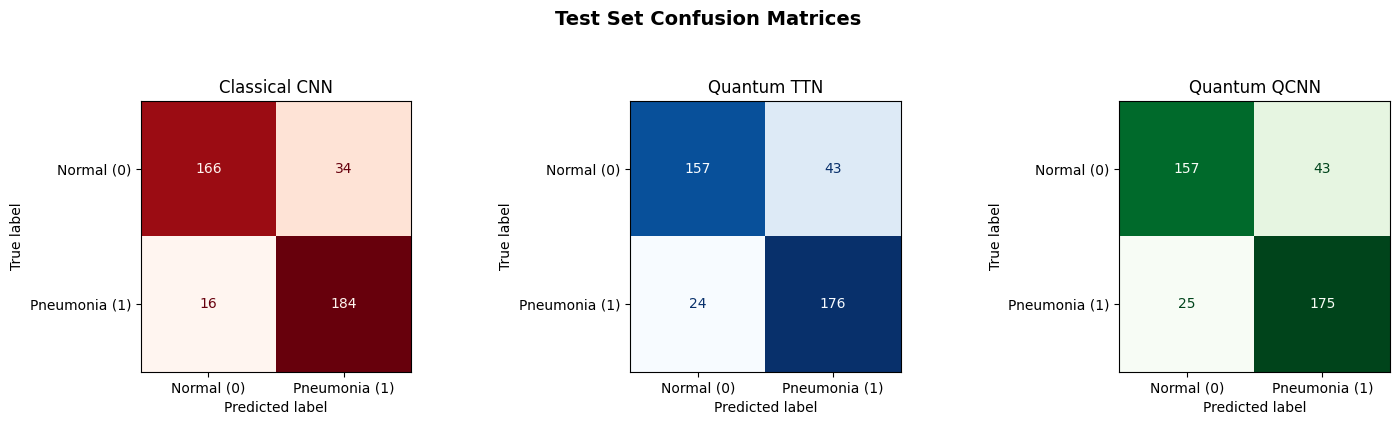

In [38]:
# --- PLOT 3: Confusion Matrices ---
fig3, axes = plt.subplots(1, 3, figsize=(15, 4))
class_names = ['Normal (0)', 'Pneumonia (1)']

disp_cnn  = ConfusionMatrixDisplay(confusion_matrix=cnn_cm,  display_labels=class_names)
disp_ttn  = ConfusionMatrixDisplay(confusion_matrix=ttn_cm,  display_labels=class_names)
disp_qcnn = ConfusionMatrixDisplay(confusion_matrix=qcnn_cm, display_labels=class_names)

disp_cnn.plot(ax=axes[0],  cmap='Reds',   colorbar=False)
disp_ttn.plot(ax=axes[1],  cmap='Blues',  colorbar=False)
disp_qcnn.plot(ax=axes[2], cmap='Greens', colorbar=False)

axes[0].set_title('Classical CNN')
axes[1].set_title('Quantum TTN')
axes[2].set_title('Quantum QCNN')

plt.suptitle('Test Set Confusion Matrices', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [39]:
class Hybrid_QCNN_Amp(nn.Module):
    def __init__(self):
        super(Hybrid_QCNN_Amp, self).__init__()
        # Same Circuit of previous CNN
        weight_shapes = {'weights': (TOTAL_QCNN_PARAMS,)}
        self.qlayer = qml.qnn.TorchLayer(qnode_qcnn_amp, weight_shapes)
        
        # + 1 Classical layer at the end
        # Recibe 1 valor (el valor esperado cuántico) y saca 1 valor (el logit)
        self.fc_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        # Quantum processing
        q_out = self.qlayer(x)
        
        # Adjust TorchLayer returns shape [Batch], to [Batch, 1]
        q_out = q_out.view(-1, 1) 
        
        # Classical processing and Activation
        c_out = self.fc_layer(q_out)
        prob = torch.sigmoid(c_out) # Map to [0, 1] with Sigmoid
        
        return prob

In [40]:
# --- Grid Search for Hybrid QCNN ---
best_hybrid_config = None
best_hybrid_loss = float('inf')
best_hybrid_model = None

print("\nSearching hiperparameters for Hybrid QCNN")
for lr in quantum_lrs:
    model = Hybrid_QCNN_Amp()
    model.apply(init_quantum_weights)
    opt = optim.Adam(model.parameters(), lr=lr)
    
    print(f"Training Hybrid QCNN -> LR: {lr}", end="... ")
    val_loss, val_acc, best_ep, hist, trained_model = train_and_evaluate(model, opt, train_loader, test_loader, epochs=n_epochs)
    print(f"Best Test Loss: {val_loss:.4f} (Epoch {best_ep}) | Accuracy: {val_acc:.4f}")
    
    if val_loss < best_hybrid_loss:
        best_hybrid_loss = val_loss
        best_hybrid_config = {'lr': lr, 'hist': hist}
        best_hybrid_model = trained_model

print(f"Best Hybrid QCNN : LR={best_hybrid_config['lr']}")


Searching hiperparameters for Hybrid QCNN
Training Hybrid QCNN -> LR: 0.05... Best Test Loss: 0.3729 (Epoch 9) | Accuracy: 0.8550
Training Hybrid QCNN -> LR: 0.01... Best Test Loss: 0.3697 (Epoch 30) | Accuracy: 0.8625
Training Hybrid QCNN -> LR: 0.005... Best Test Loss: 0.4409 (Epoch 29) | Accuracy: 0.8450
Training Hybrid QCNN -> LR: 0.001... Best Test Loss: 0.6305 (Epoch 30) | Accuracy: 0.8125
Training Hybrid QCNN -> LR: 0.0005... Best Test Loss: 0.6675 (Epoch 30) | Accuracy: 0.6750
Best Hybrid QCNN : LR=0.01


In [43]:
# ==========================================
# Hybrid Pre-QCNN (Classical -> Quantum)
# ==========================================

# New Qnode with Angle Embedding
@qml.qnode(dev_qcnn, interface='torch')
def qnode_qcnn_angle(inputs, weights):

    qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='Y')
    
    idx = 0
    
    # The rest of the QCNN is the same
    # --- Layer 1 ---
    all_wires = list(range(8))
    conv_layer(weights[idx : idx+N_C1].reshape(-1, 6), all_wires)
    idx += N_C1
    sinks1, sources1 = [0, 2, 4, 6], [1, 3, 5, 7]
    pool_layer(weights[idx : idx+N_P1].reshape(-1, 2), sinks1, sources1)
    idx += N_P1
    
    # --- Layer 2 ---
    conv_layer(weights[idx : idx+N_C2].reshape(-1, 6), sinks1)
    idx += N_C2
    sinks2, sources2 = [0, 4], [2, 6]
    pool_layer(weights[idx : idx+N_P2].reshape(-1, 2), sinks2, sources2)
    idx += N_P2
    
    # --- Layer 3 ---
    conv_layer(weights[idx : idx+N_C3].reshape(-1, 6), sinks2)
    idx += N_C3
    sinks3, sources3 = [0], [4]
    pool_layer(weights[idx : idx+N_P3].reshape(-1, 2), sinks3, sources3)
    
    return qml.expval(qml.PauliZ(0))

# Pytorch Model definition
class Hybrid_Pre_QCNN(nn.Module):
    def __init__(self):
        super(Hybrid_Pre_QCNN, self).__init__()
        # 256 entry characteristics -> 32 -> 8
        self.feature_extractor = nn.Sequential(
            nn.Linear(256, 32),
            nn.ReLU(),
            nn.Linear(32, 8)
        )
        
        weight_shapes = {'weights': (TOTAL_QCNN_PARAMS,)}
        self.qlayer = qml.qnn.TorchLayer(qnode_qcnn_angle, weight_shapes)

    def forward(self, x):
        # Reduce Dimensionality
        features = self.feature_extractor(x)
        
        # We bound the classical values ​​between [-pi, pi] using Tanh to act well with AngleEmbedding
        angles = torch.tanh(features) * np.pi
        
        # Quantum Processing
        q_out = self.qlayer(angles)
        
        # Final Mapping
        prob = ((q_out + 1.0) / 2.0).view(-1, 1)
        return prob


In [44]:
# Grid Search for Hybrid Pre-QCNN
best_pre_hybrid_config = None
best_pre_hybrid_loss = float('inf')
best_pre_hybrid_model = None

print("\nSearching hyperparameters for Hybrid Pre-QCNN (Class -> Quant)")
for lr in quantum_lrs:
    model = Hybrid_Pre_QCNN()
    # Classical layers init random, quantum layers with init near 0
    model.apply(init_quantum_weights) 
    opt = optim.Adam(model.parameters(), lr=lr)
    
    print(f"Training Hybrid Pre-QCNN -> LR: {lr}", end="... ")
    val_loss, val_acc, best_ep, hist, trained_model = train_and_evaluate(model, opt, train_loader, test_loader, epochs=n_epochs)
    print(f"Best Test Loss: {val_loss:.4f} (Epoch {best_ep}) | Accuracy: {val_acc:.4f}")
    
    if val_loss < best_pre_hybrid_loss:
        best_pre_hybrid_loss = val_loss
        best_pre_hybrid_config = {'lr': lr, 'hist': hist}
        best_pre_hybrid_model = trained_model

print(f"\nBest Hybrid Pre-QCNN : LR={best_pre_hybrid_config['lr']}")


Searching hyperparameters for Hybrid Pre-QCNN (Class -> Quant)
Training Hybrid Pre-QCNN -> LR: 0.05... Best Test Loss: 0.6931 (Epoch 10) | Accuracy: 0.5000
Training Hybrid Pre-QCNN -> LR: 0.01... Best Test Loss: 0.3661 (Epoch 6) | Accuracy: 0.8475
Training Hybrid Pre-QCNN -> LR: 0.005... Best Test Loss: 0.3737 (Epoch 3) | Accuracy: 0.8525
Training Hybrid Pre-QCNN -> LR: 0.001... Best Test Loss: 0.3780 (Epoch 6) | Accuracy: 0.8450
Training Hybrid Pre-QCNN -> LR: 0.0005... Best Test Loss: 0.3756 (Epoch 9) | Accuracy: 0.8425

Best Hybrid Pre-QCNN : LR=0.01


In [45]:
# --- Obtain predictions ---
cnn_preds,        true_labels = get_predictions(best_cnn_model, test_loader)
ttn_preds,        _           = get_predictions(best_ttn_model, test_loader)
qcnn_preds,       _           = get_predictions(best_qcnn_model, test_loader)
hybrid_preds,     _           = get_predictions(best_hybrid_model, test_loader) 
pre_hybrid_preds, _           = get_predictions(best_pre_hybrid_model, test_loader) 

# --- Calculate Metrics ---
cnn_acc, cnn_rec, cnn_f1, cnn_cm                = calc_metrics(cnn_preds, true_labels)
ttn_acc, ttn_rec, ttn_f1, ttn_cm                = calc_metrics(ttn_preds, true_labels)
qcnn_acc, qcnn_rec, qcnn_f1, qcnn_cm            = calc_metrics(qcnn_preds, true_labels)
hybrid_acc, hybrid_rec, hybrid_f1, hybrid_cm    = calc_metrics(hybrid_preds, true_labels) 
pre_hyb_acc, pre_hyb_rec, pre_hyb_f1, pre_hyb_cm = calc_metrics(pre_hybrid_preds, true_labels) 

# --- Loss history ---
history = {
    'cnn_tr_loss': best_cnn_config['hist']['tr_loss'], 'cnn_te_loss': best_cnn_config['hist']['te_loss'],
    'ttn_tr_loss': best_ttn_config['hist']['tr_loss'], 'ttn_te_loss': best_ttn_config['hist']['te_loss'],
    'qcnn_tr_loss': best_qcnn_config['hist']['tr_loss'], 'qcnn_te_loss': best_qcnn_config['hist']['te_loss'],
    'hybrid_tr_loss': best_hybrid_config['hist']['tr_loss'], 'hybrid_te_loss': best_hybrid_config['hist']['te_loss'],
    'pre_hybrid_tr_loss': best_pre_hybrid_config['hist']['tr_loss'], 'pre_hybrid_te_loss': best_pre_hybrid_config['hist']['te_loss']
}


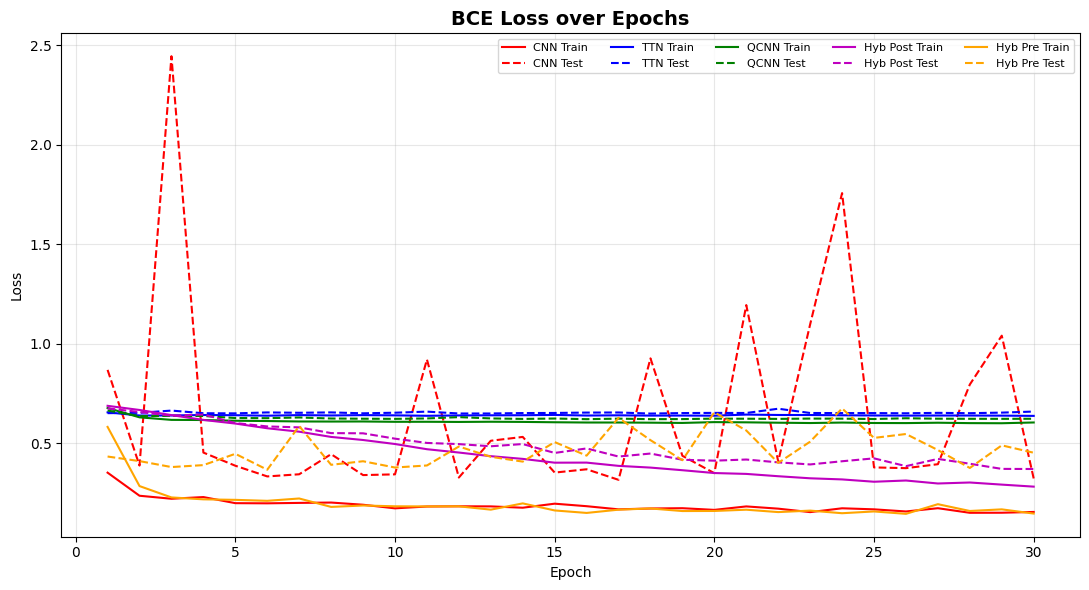

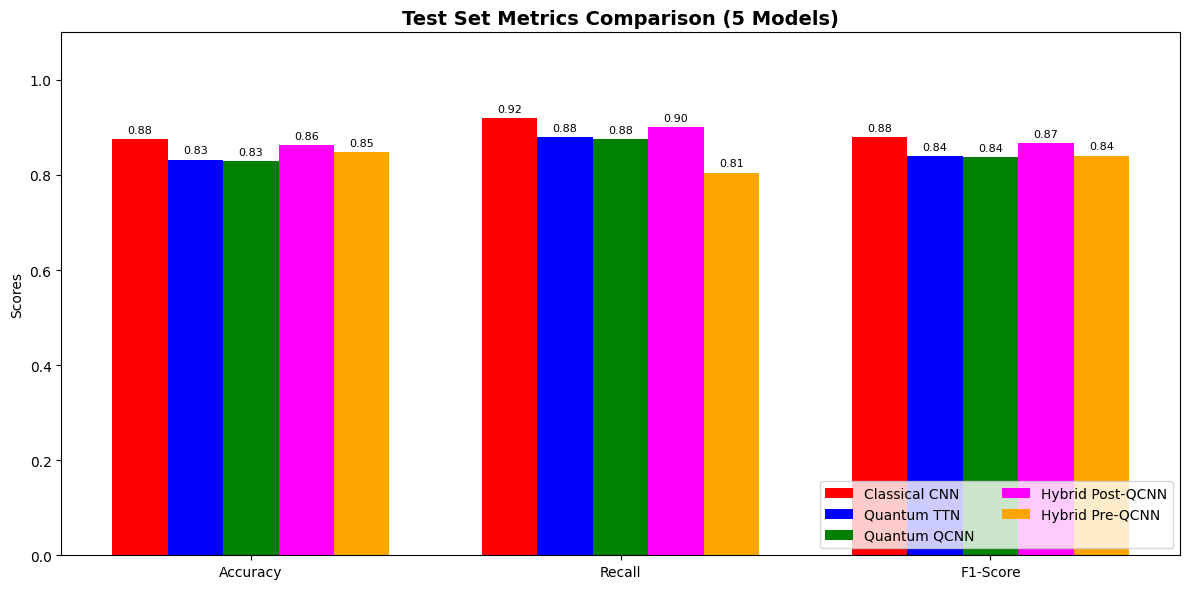

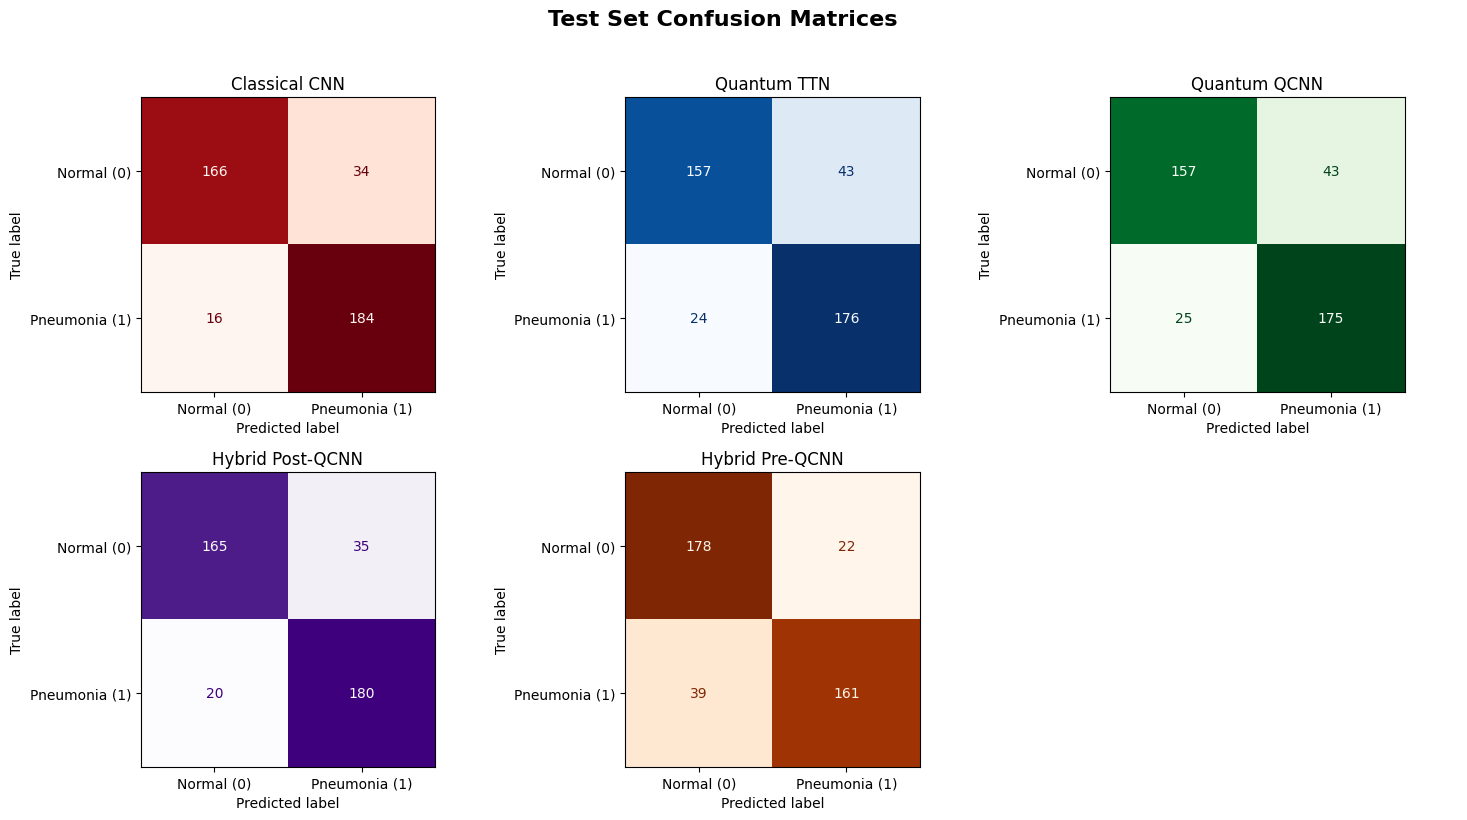

In [46]:
# ==========================================
# 5. PLOTTING THE RESULTS (Updated for 5 models)
# ==========================================
plt.style.use('default')
epochs_range = range(1, n_epochs + 1)

# --- PLOT 1: Loss Curves ---
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(epochs_range, history['cnn_tr_loss'],        'r-',  label='CNN Train')
ax1.plot(epochs_range, history['cnn_te_loss'],        'r--', label='CNN Test')
ax1.plot(epochs_range, history['ttn_tr_loss'],        'b-',  label='TTN Train')
ax1.plot(epochs_range, history['ttn_te_loss'],        'b--', label='TTN Test')
ax1.plot(epochs_range, history['qcnn_tr_loss'],       'g-',  label='QCNN Train')
ax1.plot(epochs_range, history['qcnn_te_loss'],       'g--', label='QCNN Test')
ax1.plot(epochs_range, history['hybrid_tr_loss'],     'm-',  label='Hyb Post Train')
ax1.plot(epochs_range, history['hybrid_te_loss'],     'm--', label='Hyb Post Test')
# Añadimos el nuevo Híbrido en color Naranja
ax1.plot(epochs_range, history['pre_hybrid_tr_loss'], color='orange', linestyle='-',  label='Hyb Pre Train')
ax1.plot(epochs_range, history['pre_hybrid_te_loss'], color='orange', linestyle='--', label='Hyb Pre Test')

ax1.set_title("BCE Loss over Epochs", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', ncol=5, fontsize=8)
plt.tight_layout()
plt.show()


# --- PLOT 2: Bar Plots ---
fig2, ax2 = plt.subplots(figsize=(12, 6))

labels = ['Accuracy', 'Recall', 'F1-Score']
cnn_scores    = [cnn_acc, cnn_rec, cnn_f1]
ttn_scores    = [ttn_acc, ttn_rec, ttn_f1]
qcnn_scores   = [qcnn_acc, qcnn_rec, qcnn_f1]
hybrid_scores = [hybrid_acc, hybrid_rec, hybrid_f1]
pre_hyb_scores= [pre_hyb_acc, pre_hyb_rec, pre_hyb_f1]

x = np.arange(len(labels)) 
width = 0.15 # Ancho reducido para 5 barras

rects1 = ax2.bar(x - 2*width, cnn_scores,     width, label='Classical CNN', color='red')
rects2 = ax2.bar(x - width,   ttn_scores,     width, label='Quantum TTN', color='blue')
rects3 = ax2.bar(x,           qcnn_scores,    width, label='Quantum QCNN', color='green')
rects4 = ax2.bar(x + width,   hybrid_scores,  width, label='Hybrid Post-QCNN', color='magenta')
rects5 = ax2.bar(x + 2*width, pre_hyb_scores, width, label='Hybrid Pre-QCNN', color='orange')

ax2.set_ylabel('Scores')
ax2.set_title('Test Set Metrics Comparison (5 Models)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1.1)
ax2.legend(loc='lower right', ncol=2)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1); autolabel(rects2); autolabel(rects3); autolabel(rects4); autolabel(rects5)
plt.tight_layout()
plt.show()


# --- PLOT 3: Confusion Matrices (2x3 Grid) ---
fig3, axes = plt.subplots(2, 3, figsize=(15, 8))
class_names = ['Normal (0)', 'Pneumonia (1)']

disp_cnn      = ConfusionMatrixDisplay(confusion_matrix=cnn_cm,      display_labels=class_names)
disp_ttn      = ConfusionMatrixDisplay(confusion_matrix=ttn_cm,      display_labels=class_names)
disp_qcnn     = ConfusionMatrixDisplay(confusion_matrix=qcnn_cm,     display_labels=class_names)
disp_hybrid   = ConfusionMatrixDisplay(confusion_matrix=hybrid_cm,   display_labels=class_names)
disp_pre_hyb  = ConfusionMatrixDisplay(confusion_matrix=pre_hyb_cm,  display_labels=class_names)

# Fila superior
disp_cnn.plot(ax=axes[0, 0],  cmap='Reds',   colorbar=False)
axes[0, 0].set_title('Classical CNN')

disp_ttn.plot(ax=axes[0, 1],  cmap='Blues',  colorbar=False)
axes[0, 1].set_title('Quantum TTN')

disp_qcnn.plot(ax=axes[0, 2], cmap='Greens', colorbar=False)
axes[0, 2].set_title('Quantum QCNN')

# Fila inferior
disp_hybrid.plot(ax=axes[1, 0], cmap='Purples', colorbar=False)
axes[1, 0].set_title('Hybrid Post-QCNN')

disp_pre_hyb.plot(ax=axes[1, 1], cmap='Oranges', colorbar=False)
axes[1, 1].set_title('Hybrid Pre-QCNN')

# Quitamos el último plot vacío
axes[1, 2].axis('off')

plt.suptitle('Test Set Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()